# Part 4 — Scaffold-Aware CV & Baseline Models

Based on the issues raised by Greg Landrum (2023, 2024), we used **Butina cluster‑based cross‑validation** instead of a standard Murcko scaffold split.

- Landrum (2024) showed that Bemis‑Murcko scaffolds severely over‑fragment real medicinal chemistry series: a typical paper with ~30 compounds often yields ~12 different Murcko scaffolds, whereas a single chemical series defined by the authors covers most of the data. This makes Murcko splits unrealistic for evaluating generalization to new scaffolds.  
  → [The problem(s) with scaffold splits, part 1 (2024)](https://greglandrum.github.io/rdkit-blog/posts/2024-05-31-scaffold-splits-and-murcko-scaffolds1.html)

- Landrum (2023) demonstrated that cross‑validation results can vary substantially depending on how the data are partitioned, reinforcing the need for a clustering strategy that respects the natural grouping of chemical series.  
  → [Variability of x-fold cross validation results (2023)](https://greglandrum.github.io/rdkit-blog/posts/2023-08-13-xval-variability1.html)

Consequently, we adopted Butina clustering to define training and test folds, ensuring that structurally similar compounds remain together and avoiding the artificial fragmentation introduced by Murcko scaffolds.

## Two tasks

| Task | Target | Metrics |
|---|---|---|
| **Regression** | `pchembl_value` (continuous) | R², RMSE, MAE, Pearson r |
| **Classification** | `active / inactive` (binary) | AUC-ROC, Balanced Accuracy, MCC, macro-F1 |


---
## 0. Installs & Imports

In [26]:
import numpy as np
import pandas as pd
import warnings
import pickle
warnings.filterwarnings('ignore')

from rdkit import Chem

import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn — models
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

from sklearn.metrics import r2_score,  confusion_matrix, ConfusionMatrixDisplay

RANDOM_STATE = 42
print('All imports OK')

All imports OK


---
## 1. Load Data

In [2]:
# ── Feature matrices (from Part 3) ───────────────────────────────────────────
X_ecfp6_df   = pd.read_csv('../data/processed/X_ecfp6.csv')
X_maccs_df   = pd.read_csv('../data/processed/X_maccs.csv')
X_rdkit2d_df = pd.read_csv('../data/processed/X_rdkit2d.csv')

# ── Target variables ─────────────────────────────────────────────────────────
y_pchembl_df = pd.read_csv('../data/processed/y_pchembl.csv')   # regression
y_binary_df  = pd.read_csv('../data/processed/y_binary.csv')    # classification (active/inactive only)

# ── Molecule objects (needed for Butina clustering) ───────────────────────────
df_clean = pd.read_csv('../data/processed/egfr_bioactivity_cleaned.csv')

print(f'ECFP6 shape   : {X_ecfp6_df.shape}')
print(f'MACCS shape   : {X_maccs_df.shape}')
print(f'RDKit2D shape : {X_rdkit2d_df.shape}')
print(f'y_pchembl     : {y_pchembl_df.shape}')
print(f'y_binary      : {y_binary_df.shape}')

ECFP6 shape   : (9876, 340)
MACCS shape   : (9876, 115)
RDKit2D shape : (9876, 164)
y_pchembl     : (9876, 2)
y_binary      : (8154, 2)


In [3]:
# ── Separate molecule IDs from feature values ─────────────────────────────────
# All feature CSVs have 'molecule_chembl_id' as first column
mol_ids = X_ecfp6_df['molecule_chembl_id']

X_ecfp6   = X_ecfp6_df.drop(columns='molecule_chembl_id').values
X_maccs   = X_maccs_df.drop(columns='molecule_chembl_id').values
X_rdkit2d = X_rdkit2d_df.drop(columns='molecule_chembl_id').values

# ── Regression target: align by molecule_chembl_id ───────────────────────────
y_reg = y_pchembl_df.set_index('molecule_chembl_id').loc[mol_ids, 'pchembl_value'].values

# ── Classification target: active/inactive binary ────────────────────────────
# Binary dataset may have fewer rows
# We need to find which indices in our full dataset are active or inactive
y_binary_indexed = y_binary_df.set_index('molecule_chembl_id')
clf_mask = mol_ids.isin(y_binary_indexed.index).values 

X_ecfp6_clf   = X_ecfp6[clf_mask]
X_maccs_clf   = X_maccs[clf_mask]
X_rdkit2d_clf = X_rdkit2d[clf_mask]
mol_ids_clf   = mol_ids[clf_mask].reset_index(drop=True)

label_map = {'active': 1, 'inactive': 0}
y_clf = y_binary_indexed.loc[mol_ids_clf, 'bioactivity_class'].map(label_map).values

print(f'Regression dataset   : {len(y_reg)} compounds')
print(f'Classification dataset: {len(y_clf)} compounds')
print(f'  Active  : {y_clf.sum()}')
print(f'  Inactive: {(y_clf == 0).sum()}')
print(f'  Imbalance ratio: 1 : {(y_clf == 0).sum() / y_clf.sum():.1f}')

Regression dataset   : 9876 compounds
Classification dataset: 8154 compounds
  Active  : 7439
  Inactive: 715
  Imbalance ratio: 1 : 0.1


---
## 2. Butina Cross-Validator

We implement a **sklearn-compatible cross-validator** using Butina clustering.

How it works:
1. Compute Morgan (ECFP6) fingerprints for all molecules
2. Build a Tanimoto distance matrix (`1 - Tanimoto similarity`)
3. Cluster with Butina at `sim_cutoff=0.6` (molecules within 60% similarity → same cluster)
4. Distribute clusters across N folds (largest clusters → training; singletons → test)
5. Each fold's test set contains **whole clusters never seen in training**

This is stricter than scaffold split because it uses real pairwise similarity,
not just the core ring system.

In [5]:
# ── Butina helper functions 

from src.clustering import get_butina_clusters, assign_cluster_ids
from src.models import ButinaCrossValidator

In [6]:
# ── Build Mol objects and compute cluster IDs ─────────────────────────────────
# We need cluster IDs for ALL compounds (regression set),
# and a subset for the classification set.

print('Building RDKit Mol objects...')
mols_all = [Chem.MolFromSmiles(smi) for smi in df_clean['canonical_smiles']]

# Filter to only the molecules present in our feature matrices
# (df_clean and feature matrices should be aligned from Part 1→3)
mols_reg = [mols_all[i] for i in range(len(mol_ids))]

print('Running Butina clustering (sim_cutoff=0.6)... this may take ~1-3 min')
cluster_ids_reg = assign_cluster_ids(mols_reg, sim_cutoff=0.6)

# Subset cluster IDs for classification dataset
cluster_ids_clf = cluster_ids_reg[clf_mask]

n_clusters = len(np.unique(cluster_ids_reg))
print(f'\nDone! Found {n_clusters} clusters for {len(mols_reg)} molecules')
print(f'Avg cluster size: {len(mols_reg)/n_clusters:.1f}')

Building RDKit Mol objects...
Running Butina clustering (sim_cutoff=0.6)... this may take ~1-3 min

Done! Found 1026 clusters for 9876 molecules
Avg cluster size: 9.6


### Visualization

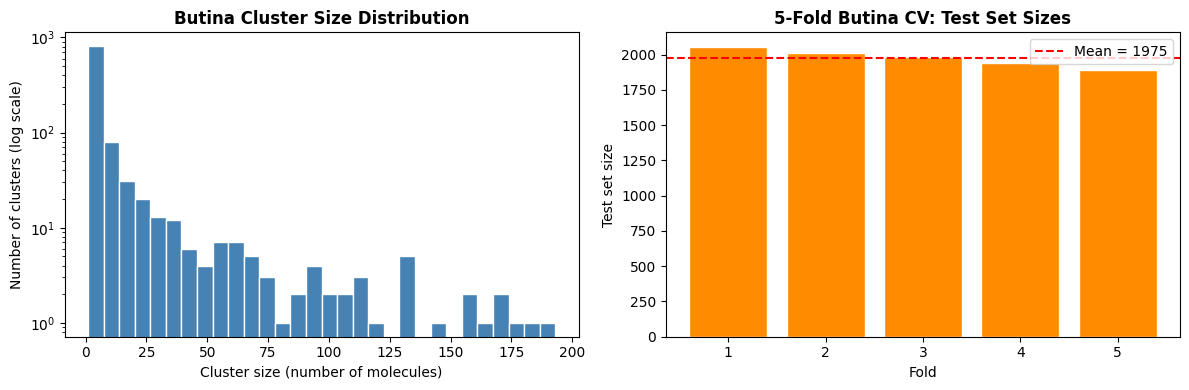

Fold sizes: [2055, 2011, 1980, 1941, 1889]


In [7]:
# ── Visualise cluster size distribution ──────────────────────────────────────
unique, counts = np.unique(cluster_ids_reg, return_counts=True)
sizes = pd.Series(counts)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Cluster size histogram
axes[0].hist(sizes, bins=30, color='steelblue', edgecolor='white', log=True)
axes[0].set_xlabel('Cluster size (number of molecules)')
axes[0].set_ylabel('Number of clusters (log scale)')
axes[0].set_title('Butina Cluster Size Distribution', fontweight='bold')

# Fold size after 5-fold assignment
cv_temp  = ButinaCrossValidator(n_splits=5)
fold_sizes = []
for train_idx, test_idx in cv_temp.split(X_ecfp6, y_reg, groups=cluster_ids_reg):
    fold_sizes.append(len(test_idx))

axes[1].bar(range(1, 6), fold_sizes, color='darkorange', edgecolor='white')
axes[1].axhline(np.mean(fold_sizes), color='red', linestyle='--', label=f'Mean = {np.mean(fold_sizes):.0f}')
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('Test set size')
axes[1].set_title('5-Fold Butina CV: Test Set Sizes', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('../figs/cv/part4_butina_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Fold sizes: {fold_sizes}')

In [8]:
# Build RDKit molecule objects from SMILES
smiles_list = df_clean['canonical_smiles'].tolist()
mols = [Chem.MolFromSmiles(smi) for smi in smiles_list]

# Regression target: raw pChEMBL values
y_pchembl = df_clean['pchembl_value'].values.astype(float)

# Classification target: use the class column from Part 1
# (active = 1, inactive= 0)
y_binary = (df_clean['bioactivity_class'] == 'active').astype(int)

# Quick sanity check — all arrays must have the same length
assert len(mols) == len(cluster_ids_reg) == len(y_binary), \
    "Length mismatch between mols, cluster_ids, and targets"

print(f"Ready: {len(mols)} molecules across {len(np.unique(cluster_ids_reg))} Butina clusters")

Ready: 9876 molecules across 1026 Butina clusters


### t-sne

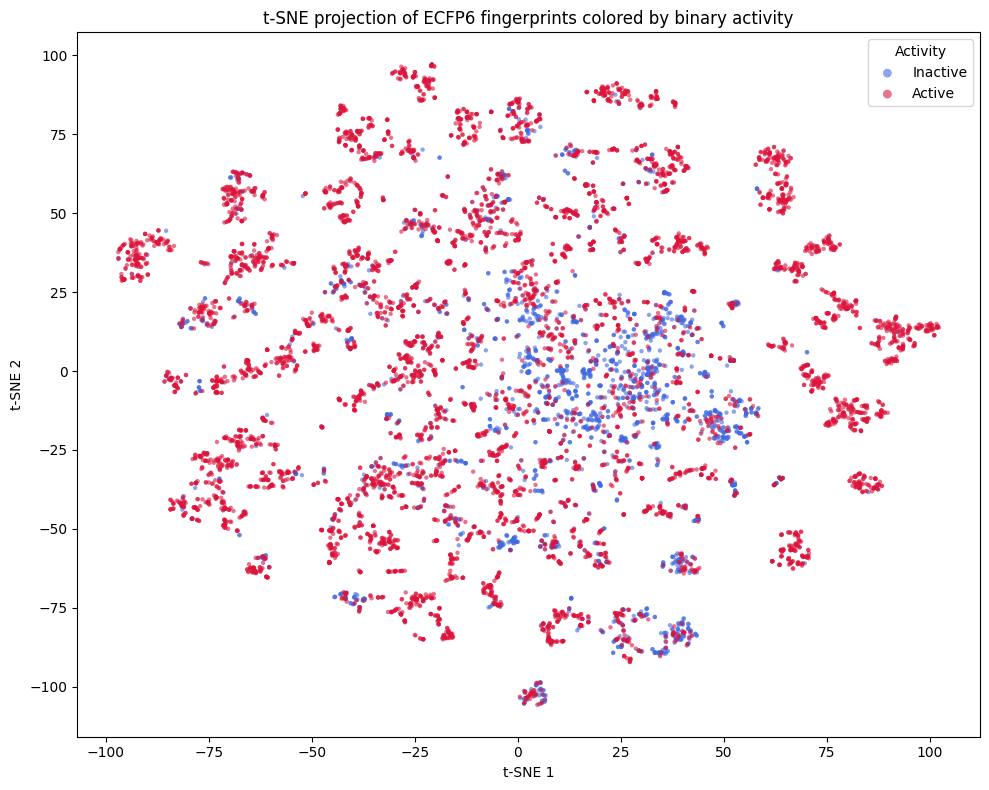

In [9]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

X_ecfp6 = X_ecfp6_df.iloc[:, 1:].values.astype(np.float32)  # keeping numeric colms

# PCA
pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X_ecfp6)

# t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
X_tsne = tsne.fit_transform(X_pca)


plt.figure(figsize=(10, 8))


colors = {0: 'royalblue', 1: 'crimson'}   
labels = {0: 'Inactive', 1: 'Active'}

for activity_value in [0, 1]:
    mask = y_binary == activity_value
    plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1], 
                c=colors[activity_value], label=labels[activity_value],
                s=10, alpha=0.6, edgecolors='none')

plt.legend(title='Activity', markerscale=2)
plt.title('t-SNE projection of ECFP6 fingerprints colored by binary activity')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.tight_layout()
plt.savefig('../figs/cv/tsne_bioactivity_discrete.png', dpi=150)
plt.show()

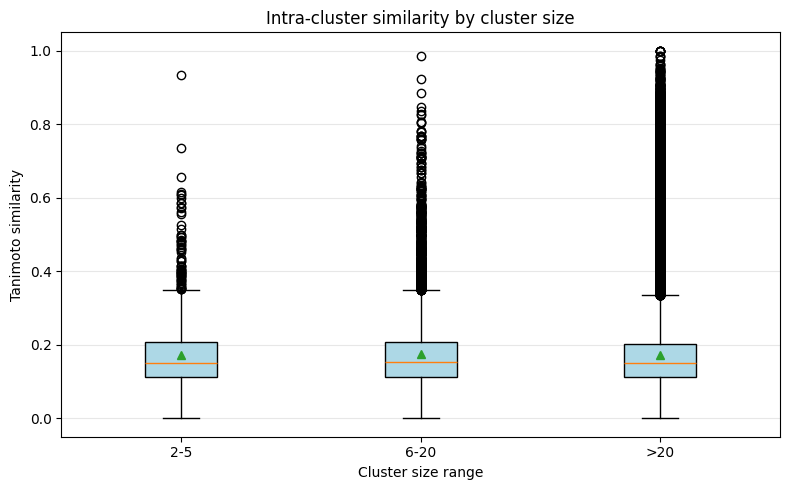

In [10]:
from src.clustering import intra_cluster_sims_by_size

sims_by_size = intra_cluster_sims_by_size(cluster_ids_reg, X_ecfp6)

plt.figure(figsize=(8,5))
plt.boxplot([sims_by_size['2-5'], sims_by_size['6-20'], sims_by_size['>20']],
            labels=['2-5', '6-20', '>20'], showmeans=True,
            patch_artist=True, boxprops=dict(facecolor='lightblue'))
plt.ylabel('Tanimoto similarity')
plt.xlabel('Cluster size range')
plt.title('Intra‑cluster similarity by cluster size')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../figs/cv/intracluster_boxplot.png', dpi=150)
plt.show()


  Cluster 0  ---  193 member(s)


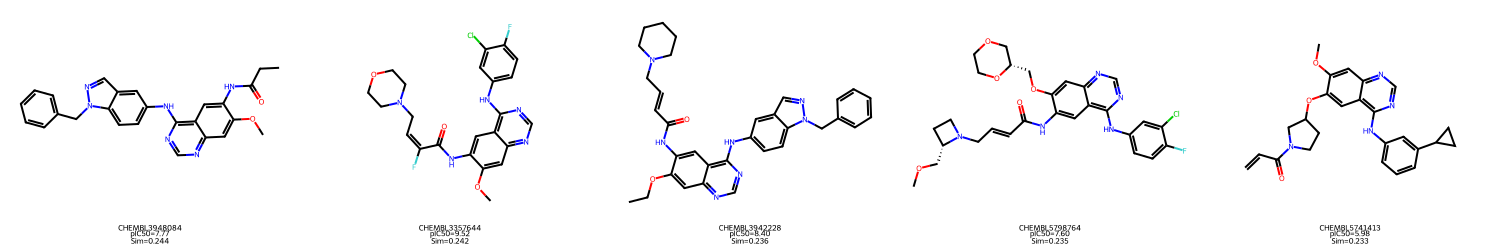

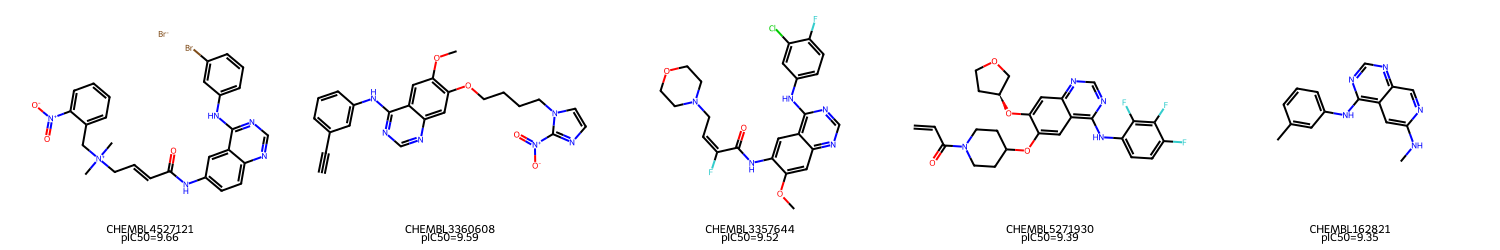


SVG images saved in: ../figs/../figs/cv/cluster0_centroids
  - 5_most_REPRESENTATIVE.svg
  - 5_most_ACTIVE.svg


('<svg xmlns="http://www.w3.org/2000/svg" xmlns:rdkit="http://www.rdkit.org/xml" xmlns:xlink="http://www.w3.org/1999/xlink" version="1.1" baseProfile="full" xml:space="preserve" width="1500px" height="250px" viewBox="0 0 1500 250">\n<!-- END OF HEADER -->\n<rect style="opacity:0.0;fill:#FFFFFF;stroke:none" width="1500.0" height="250.0" x="0.0" y="0.0"> </rect>\n<path class="bond-0 atom-0 atom-1" d="M 279.1,67.8 L 260.0,68.7" style="fill:none;fill-rule:evenodd;stroke:#000000;stroke-width:2.0px;stroke-linecap:butt;stroke-linejoin:miter;stroke-opacity:1"/>\n<path class="bond-1 atom-1 atom-2" d="M 260.0,68.7 L 251.2,85.7" style="fill:none;fill-rule:evenodd;stroke:#000000;stroke-width:2.0px;stroke-linecap:butt;stroke-linejoin:miter;stroke-opacity:1"/>\n<path class="bond-2 atom-2 atom-3" d="M 249.5,85.8 L 253.8,92.5" style="fill:none;fill-rule:evenodd;stroke:#000000;stroke-width:2.0px;stroke-linecap:butt;stroke-linejoin:miter;stroke-opacity:1"/>\n<path class="bond-2 atom-2 atom-3" d="M 253.8

In [11]:
# ── Fingerprint matrix (needed for similarity calculations) ──────────────────
# Drop the molecule_chembl_id column to get a pure numeric matrix
X_ecfp6_fp = X_ecfp6_df.drop(columns='molecule_chembl_id').values.astype(np.float32)

# ── Lists needed for visualisation ────────────────────────────────────────────
smiles_list = df_clean['canonical_smiles'].tolist()
mol_id_list = df_clean['molecule_chembl_id'].tolist()
mols = [Chem.MolFromSmiles(sm) for sm in smiles_list]
y_pchembl_vals = df_clean['pchembl_value'].values.astype(float)


# This funtion will show the 5 more representative molecules of x cluster + the 5 more active
from src.clustering import visualize_cluster


visualize_cluster(cluster_id=0, ids=cluster_ids_reg, X_fp=X_ecfp6_fp, y_vals=y_pchembl_vals, mols=mols, mol_id_list=mol_id_list)

---
## 4. Baseline: Random Forest — Regression

We run each of the three feature sets through the same RF regressor
under identical Butina 5-fold CV conditions.
This gives a clean **feature ablation** table.

In [12]:
from src.models import regression_metrics, classification_metrics, run_butina_cv_regression, run_butina_cv_classification

In [15]:
rf_reg = RandomForestRegressor(
    n_estimators=500,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

feature_sets_reg = {
    'ECFP6'   : X_ecfp6,
    'MACCS'   : X_maccs,
    'RDKit_2D': X_rdkit2d,
}

reg_results = {}

for name, X_feat in feature_sets_reg.items():
    print(f'Running regression CV with {name} ({X_feat.shape[1]} features)...')
    res = run_butina_cv_regression(
        model=rf_reg, X=X_feat, y=y_reg,
        cluster_ids=cluster_ids_reg, n_splits=5
    )
    reg_results[name] = res
    mean = res.loc['mean']
    std  = res.loc['std']
    print(f'  R²={mean.R2:.3f}±{std.R2:.3f}  RMSE={mean.RMSE:.3f}±{std.RMSE:.3f}  '
          f'MAE={mean.MAE:.3f}  r={mean.Pearson_r:.3f}\n')

Running regression CV with ECFP6 (339 features)...
  R²=0.707±0.014  RMSE=0.697±0.016  MAE=0.511  r=0.841

Running regression CV with MACCS (114 features)...
  R²=0.632±0.015  RMSE=0.781±0.013  MAE=0.579  r=0.795

Running regression CV with RDKit_2D (163 features)...
  R²=0.662±0.014  RMSE=0.748±0.016  MAE=0.560  r=0.818



In [17]:
# ── Regression results table ──────────────────────────────────────────────────
reg_summary = pd.DataFrame([
    {
        'Feature set': name,
        'n_features' : feature_sets_reg[name].shape[1],
        'R² mean'    : f"{reg_results[name].loc['mean','R2']:.3f}",
        'R² std'     : f"±{reg_results[name].loc['std','R2']:.3f}",
        'RMSE'       : f"{reg_results[name].loc['mean','RMSE']:.3f}",
        'MAE'        : f"{reg_results[name].loc['mean','MAE']:.3f}",
        'Pearson r'  : f"{reg_results[name].loc['mean','Pearson_r']:.3f}",
    }
    for name in feature_sets_reg
])

# Literature benchmark row
reg_summary.loc[len(reg_summary)] = [
    'SVR (Vignaux 2023)', '—', '0.810', '—', '0.730', '0.550', '0.760'
]

print('=== REGRESSION RESULTS (Butina 5-fold CV) ===')
print(reg_summary.to_string(index=False))
reg_summary.to_csv('../data/results/part4_regression_results.csv', index=False)

=== REGRESSION RESULTS (Butina 5-fold CV) ===
       Feature set n_features R² mean R² std  RMSE   MAE Pearson r
             ECFP6        339   0.707 ±0.014 0.697 0.511     0.841
             MACCS        114   0.632 ±0.015 0.781 0.579     0.795
          RDKit_2D        163   0.662 ±0.014 0.748 0.560     0.818
SVR (Vignaux 2023)          —   0.810      — 0.730 0.550     0.760


---
## 5. Baseline: Random Forest — Classification

**MCC (Matthews Correlation Coefficient)**  It ranges from -1 to +1, where +1 = perfect, 0 = random.

In [18]:
rf_clf = RandomForestClassifier(
    n_estimators=500,
    class_weight='balanced',   # handles active/inactive imbalance
    random_state=RANDOM_STATE,
    n_jobs=-1
)

feature_sets_clf = {
    'ECFP6'   : X_ecfp6_clf,
    'MACCS'   : X_maccs_clf,
    'RDKit_2D': X_rdkit2d_clf,
}

clf_results = {}

for name, X_feat in feature_sets_clf.items():
    print(f'Running classification CV with {name} ({X_feat.shape[1]} features)...')
    res = run_butina_cv_classification(
        model=rf_clf, X=X_feat, y=y_clf,
        cluster_ids=cluster_ids_clf, n_splits=5
    )
    clf_results[name] = res
    mean = res.loc['mean']
    std  = res.loc['std']
    print(f'  AUC={mean.AUC:.3f}±{std.AUC:.3f}  BalAcc={mean.BalancedAcc:.3f}  '
          f'MCC={mean.MCC:.3f}  F1={mean.MacroF1:.3f}\n')

Running classification CV with ECFP6 (339 features)...
  AUC=0.973±0.007  BalAcc=0.838  MCC=0.734  F1=0.865

Running classification CV with MACCS (114 features)...
  AUC=0.967±0.011  BalAcc=0.796  MCC=0.683  F1=0.836

Running classification CV with RDKit_2D (163 features)...
  AUC=0.968±0.006  BalAcc=0.767  MCC=0.663  F1=0.820



In [19]:
# ── Classification results table ──────────────────────────────────────────────
clf_summary = pd.DataFrame([
    {
        'Feature set'  : name,
        'n_features'   : feature_sets_clf[name].shape[1],
        'AUC mean'     : f"{clf_results[name].loc['mean','AUC']:.3f}",
        'AUC std'      : f"±{clf_results[name].loc['std','AUC']:.3f}",
        'BalancedAcc'  : f"{clf_results[name].loc['mean','BalancedAcc']:.3f}",
        'MCC'          : f"{clf_results[name].loc['mean','MCC']:.3f}",
        'Macro F1'     : f"{clf_results[name].loc['mean','MacroF1']:.3f}",
    }
    for name in feature_sets_clf
])

# DeepEGFR uses F1 ~0.94 for GNN — much harder to match
clf_summary.loc[len(clf_summary)] = [
    'GNN (DeepEGFR 2025)', '—', '—', '—', '—', '—', '~0.94'
]

print('=== CLASSIFICATION RESULTS (Butina 5-fold CV) ===')
print(clf_summary.to_string(index=False))
clf_summary.to_csv('../data/results/part4_classification_results.csv', index=False)

=== CLASSIFICATION RESULTS (Butina 5-fold CV) ===
        Feature set n_features AUC mean AUC std BalancedAcc   MCC Macro F1
              ECFP6        339    0.973  ±0.007       0.838 0.734    0.865
              MACCS        114    0.967  ±0.011       0.796 0.683    0.836
           RDKit_2D        163    0.968  ±0.006       0.767 0.663    0.820
GNN (DeepEGFR 2025)          —        —       —           —     —    ~0.94


---
## 6. Key Figures

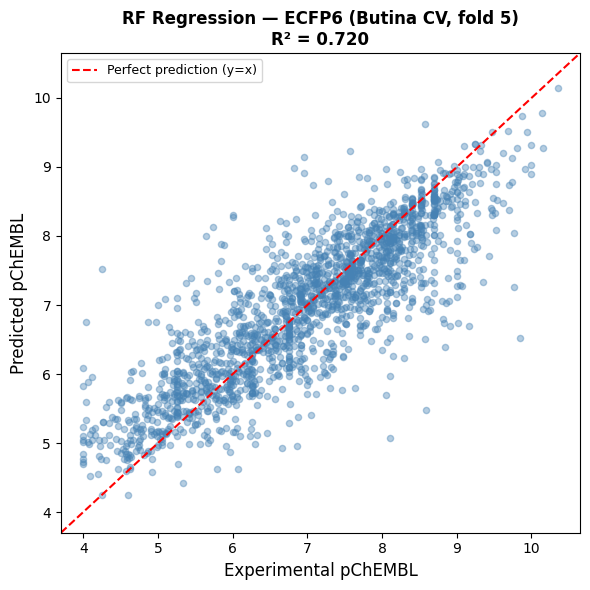

In [22]:
# ── Figure 1: Experimental vs Predicted pIC50 (best feature set, last fold) ──
# Re-run the last fold of the best-performing feature set to get y_test / y_pred

best_feat_name = max(
    reg_results,
    key=lambda n: float(reg_results[n].loc['mean', 'R2'])
)
X_best = feature_sets_reg[best_feat_name]

cv = ButinaCrossValidator(n_splits=5)
splits = list(cv.split(X_best, y_reg, groups=cluster_ids_reg))
train_idx, test_idx = splits[-1]   # last fold for the plot

rf_reg.fit(X_best[train_idx], y_reg[train_idx])
y_pred_plot = rf_reg.predict(X_best[test_idx])
y_test_plot = y_reg[test_idx]

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test_plot, y_pred_plot, alpha=0.4, s=20, color='steelblue')
lims = [min(y_test_plot.min(), y_pred_plot.min()) - 0.3,
        max(y_test_plot.max(), y_pred_plot.max()) + 0.3]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction (y=x)')
r2 = r2_score(y_test_plot, y_pred_plot)
ax.set_xlabel('Experimental pChEMBL', fontsize=12)
ax.set_ylabel('Predicted pChEMBL', fontsize=12)
ax.set_title(f'RF Regression — {best_feat_name} (Butina CV, fold 5)\nR² = {r2:.3f}',
             fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(lims); ax.set_ylim(lims)
plt.tight_layout()
plt.savefig('../figs/cv/part4_regression_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

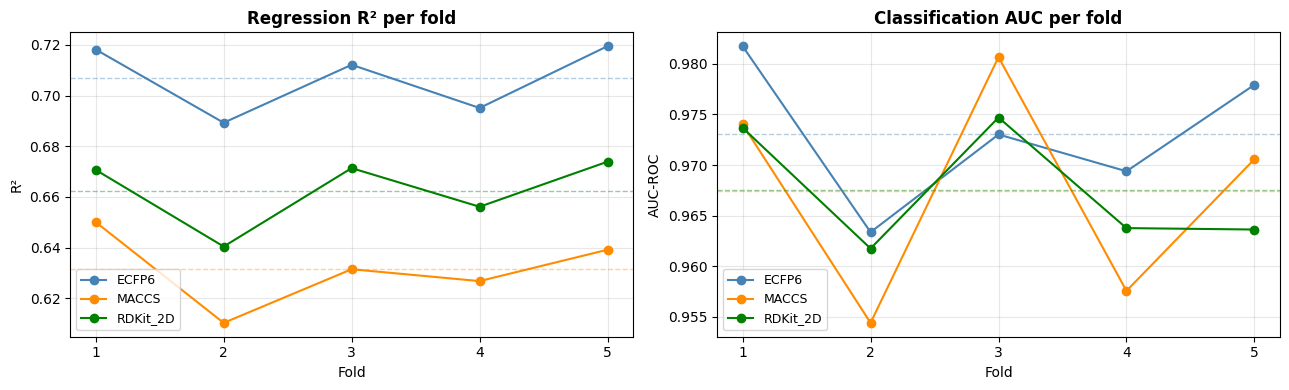

In [25]:
# ── Figure 2: R² per fold — shows variance across folds ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

colors = ['steelblue', 'darkorange', 'green']
fold_labels = [1, 2, 3, 4, 5]

for ax, (metric, ylabel, title) in zip(
    axes,
    [('R2', 'R²', 'Regression R² per fold'),
     ('AUC', 'AUC-ROC', 'Classification AUC per fold')]
):
    if metric == 'R2':
        results_dict = reg_results
    else:
        results_dict = clf_results

    for (name, res), color in zip(results_dict.items(), colors):
        fold_vals = res.loc[[1,2,3,4,5], metric].astype(float)
        ax.plot(fold_labels, fold_vals, 'o-', color=color,
                label=name, linewidth=1.5, markersize=6)
        mean_val = res.loc['mean', metric]
        ax.axhline(mean_val, color=color, linestyle='--', alpha=0.4, linewidth=1)

    ax.set_xlabel('Fold')
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_xticks(fold_labels)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../figs/cv/part4_cv_folds.png', dpi=150, bbox_inches='tight')
plt.show()

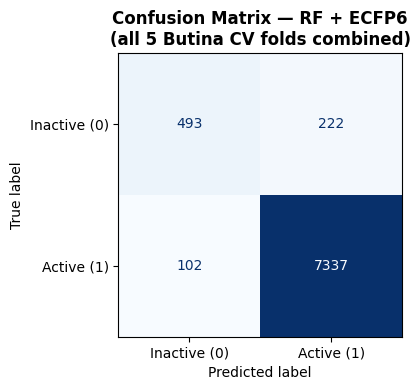

In [28]:
# ── Figure 3: Confusion matrix for best classification feature set ─────────────
best_clf_feat = max(
    clf_results,
    key=lambda n: float(clf_results[n].loc['mean', 'AUC'])
)
X_best_clf = feature_sets_clf[best_clf_feat]

cv_clf = ButinaCrossValidator(n_splits=5)
all_y_true, all_y_pred = [], []

for train_idx, test_idx in cv_clf.split(X_best_clf, y_clf, groups=cluster_ids_clf):
    rf_clf.fit(X_best_clf[train_idx], y_clf[train_idx])
    all_y_true.extend(y_clf[test_idx])
    all_y_pred.extend(rf_clf.predict(X_best_clf[test_idx]))

cm = confusion_matrix(all_y_true, all_y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Inactive (0)', 'Active (1)']
)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix — RF + {best_clf_feat}\n(all 5 Butina CV folds combined)',
             fontweight='bold')
plt.tight_layout()
plt.savefig('../figs/cv/part4_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [29]:
tn, fp, fn, tp = cm.ravel() 

accuracy = (tp+tn)/(tp+tn+fp+fn)
sensitivity = tp/(tp+fn)   # Recall
specificity = tn/(tn+fp)
precision = tp/(tp+fp)
f1 = 2 * (precision * sensitivity) / (precision + sensitivity)

print(f"\nconfusion matrix metrics (combined 5-fold CV):")
print(f"Accuracy: {accuracy:.3f}")
print(f"Sensitivity (Recall): {sensitivity:.3f}")
print(f"Specificity: {specificity:.3f}")
print(f"Precision: {precision:.3f}")
print(f"F1-score: {f1:.3f}")


confusion matrix metrics (combined 5-fold CV):
Accuracy: 0.960
Sensitivity (Recall): 0.986
Specificity: 0.690
Precision: 0.971
F1-score: 0.978


---
## 7. Save Best Model

In [30]:
# Train the best regressor on ALL data (no held-out set) for Part 6 SHAP
# Note: this model is for interpretation only — performance was already
# measured honestly via CV above. 

best_X_all = feature_sets_reg[best_feat_name]   # full dataset
rf_reg_final = RandomForestRegressor(
    n_estimators=500, random_state=RANDOM_STATE, n_jobs=-1
)
rf_reg_final.fit(best_X_all, y_reg)

with open('../models/best_rf_regressor.pkl', 'wb') as f:
    pickle.dump(rf_reg_final, f)

# Save which feature set was best (needed in Part 5/6)
with open('../models/best_feature_set.txt', 'w') as f:
    f.write(best_feat_name)

# Save cluster IDs (needed in Part 5 for consistent CV)
np.save('../data/cluster_id/butina_cluster_ids_reg.npy', cluster_ids_reg)
np.save('../data/cluster_id/butina_cluster_ids_clf.npy', cluster_ids_clf)

print(f'Saved best_rf_regressor.pkl  (trained on {best_feat_name}, {len(y_reg)} compounds)')
print(f'Saved butina_cluster_ids_reg.npy  ({len(cluster_ids_reg)} entries)')
print(f'Saved butina_cluster_ids_clf.npy  ({len(cluster_ids_clf)} entries)')

Saved best_rf_regressor.pkl  (trained on ECFP6, 9876 compounds)
Saved butina_cluster_ids_reg.npy  (9876 entries)
Saved butina_cluster_ids_clf.npy  (8154 entries)
